<a href="https://colab.research.google.com/github/jerovernay/IMC/blob/main/IMC_TP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Integrantes** \
Reynaldo Martín Peralta Recio, 428/22 \
Jeronimo Vernay, 313/24

# TP I - Trayectorias de Kepler y corrección relativista

Una corrección relativista para el problema de dos cuerpos de Kepler, sistema Sol-planeta, puede describirse en coordenadas polares con la ecuación:
$$
\ddot{u}(θ) + u(θ) - \frac{1}{α} - \delta u²(θ) = 0  
$$
Donde $u(θ) = \frac{1}{r(θ)}$, el Sol se encuentra en el origen, $α$ y $δ$ son constantes. El término con $δ$ es la corrección relativista.

1. Formular el problema como un sistema de orden uno de la forma $\dot{y} = f (θ, y)$. Observar que la variable independiente no es el tiempo sino ángulos en polares.

**Solución**:

Para formular el problema como un sistema de orden 1 de la forma $\dot{y} \,=\,f(\theta , y)$, debemos de definir un vector de estado con la variable independiente $θ$, pues la variable independiente deben de ser los angulos.

Sea:

$$\;y_1(\theta) \, = \, u(\theta) \, = \, \frac{1}{r (\theta)} \quad \text{y} \quad y_2(\theta) \, = \, \dot u(\theta) \quad ⇒ \quad y(\theta) \, = \, (y_1(\theta) \,,\, y_2(\theta)) \\[0.3cm]$$

Luego definimos el campo vectorial $\,f(\theta, y)\,$ al derivar sobre $\dot y: \\[0,2cm]$

$$\dot y \, =\, (\dot y_1\, , \, \dot y_2) \,  $$

Donde:

$$ \dot y_1 \, = \, y_2 $$
$$\dot y_2 \, = \, \ddot u \, = \, -u \, + \frac{1}{\alpha} \, \delta \, u^2 $$ $$ \dot y_2 \, = \, -y_1 \, +\, \frac{1}{\alpha} \, + \, \delta \, y_1^2 \\[0,3cm]$$

Por lo tanto:

$$\dot y \, =\, f(\theta, y)\, = \, (\dot y_1 \, , \,\dot y_2) \, = \, (\,y_2 \, , \,-y_1 \, +\, \frac{1}{\alpha} \, + \, \delta \, y_1^2\,) \\[0,3cm]$$

El estado del sistema queda definido por la inversa de la distancia radial ($\,y_1 = u(\theta)$) y su tasa de cambio respecto al ángulo ($y_2 = \dot{u}(\theta)$). Como el ángulo $\theta$ , la variable independiente, no aparece de forma explicita en las ecuaciones, obtenemos un sistema autónomo no lineal de primer orden.

&nbsp;

2. Resolver el problema de Kepler ($δ = 0$), con condiciones iniciales $r(0) = \frac{α}{1 + ϵ}$ y $\dot{r}(0) = 0$. Donde $ϵ$
es la excentricidad de la órbita: $0 ≤ ϵ < 1$ para orbitas cerradas, $ϵ ≥ 1$ para órbitas abiertas. La
condición $\dot{r}(0) = 0$ (velocidad radial cero) significa que medimos los ángulos a partir del perihelio
(punto más cercano al Sol). \
Graficar soluciones con $α = 1$ para distintos valores de $ϵ$. Observar que pasa cuando $θ > 2π$ (3 o
4 vueltas).

**Solución**:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from matplotlib import animation
from IPython.display import HTML
from matplotlib.gridspec import GridSpec

plt.style.use('default')

# =====================================================================
# --- 1. NÚCLEO MATEMÁTICO  ---
# =====================================================================

def sistema_kepler(theta, y, alpha, delta):
    """Ecuación diferencial: u'' + u = 1/alpha + delta*u^2"""

    u, u_dot = y

    return [u_dot, -u + 1/alpha + delta * (u**2)]

def integrar_sistema(epsilon, alpha, delta, vueltas, incompleto=False):
    """
    Resuelve la trayectoria.
    Para epsilon >= 1 (órbitas abiertas), limita el ángulo para evitar r -> inf.
    """

    u0 = (1 + epsilon) / alpha
    y0 = [u0, 0.0] # r_dot(0)=0 implica u_dot(0)=0

    if epsilon < 1:
        # Órbitas cerradas (elipses/círculos)

        theta_lim = 1.5 * np.pi if incompleto else vueltas * 2 * np.pi
        t_span = (0, theta_lim)
    else:
        # Órbitas abiertas (parábolas/hipérbolas)
        # El límite asintótico es arccos(-1/epsilon)

        theta_lim = np.arccos(-1.0 / epsilon) - 0.05
        t_span = (-theta_lim if not incompleto else 0, theta_lim)

    t_eval = np.linspace(t_span[0], t_span[1], 3000)
    sol = solve_ivp(sistema_kepler, t_span, y0, t_eval=t_eval,
                    args=(alpha, delta), rtol=1e-9, atol=1e-9)

    return sol.t, sol.y[0], sol.y[1] # theta, u, u_dot


def dibujar_quiver(ax, alpha, delta):
    """Dibuja el campo vectorial de fondo para el espacio de fases."""

    u_min, u_max = -0.2, 3.5
    v_min, v_max = -2.5, 2.5
    u_grid, v_grid = np.meshgrid(np.linspace(u_min, u_max, 20),
                                 np.linspace(v_min, v_max, 20))
    du = v_grid
    dv = -u_grid + 1.0/alpha + delta * (u_grid**2)
    M = np.hypot(du, dv)
    M[M == 0] = 1.0
    ax.quiver(u_grid, v_grid, du/M, dv/M, color="lightgray", alpha=0.5, pivot="mid", scale=30)
    ax.set_xlim(u_min, u_max)
    ax.set_ylim(v_min, v_max)


# --- PARÁMETROS BASE ---
alpha_base = 1.0
delta_rel = 0.05

<>:14: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:18: SyntaxWarning: invalid escape sequence '\d'
<>:31: SyntaxWarning: invalid escape sequence '\e'
<>:33: SyntaxWarning: invalid escape sequence '\d'
<>:14: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:18: SyntaxWarning: invalid escape sequence '\d'
<>:31: SyntaxWarning: invalid escape sequence '\e'
<>:33: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_5542/2157771800.py:14: SyntaxWarning: invalid escape sequence '\e'
  ax.plot(u, ud, color=col, linewidth=2, label=f'$\epsilon={eps}$')
/tmp/ipykernel_5542/2157771800.py:16: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title(f'Trayectoria $\epsilon = {eps}$')
/tmp/ipykernel_5542/2157771800.py:18: SyntaxWarning: invalid escape sequence '\d'
  ax.set_xlabel('$u$'); ax.set_ylabel('$\dot{u}$')
/tmp/ipykernel_5542/2157771800.py:31: SyntaxWarning: invalid escape sequenc

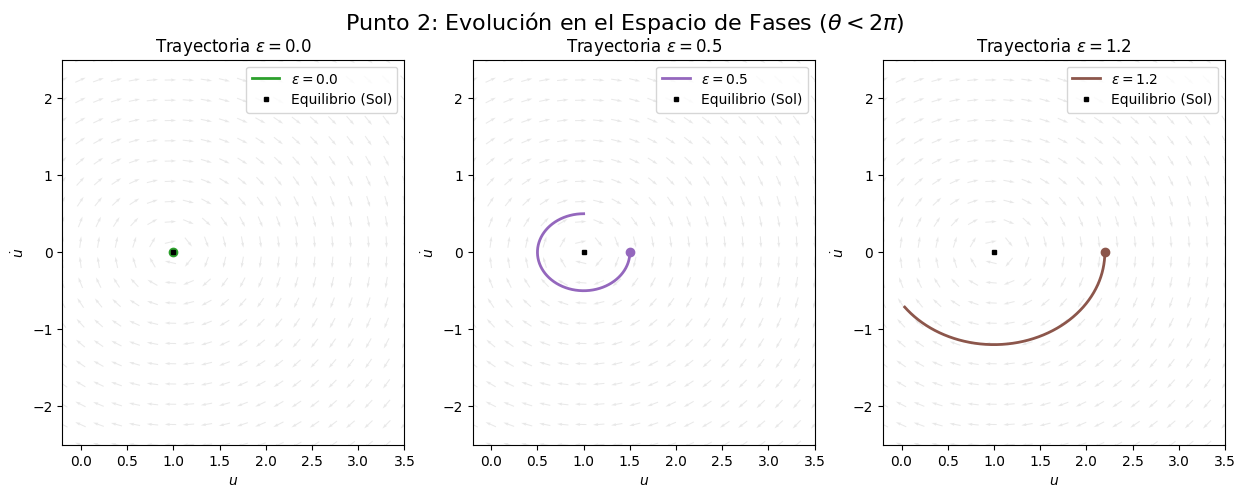

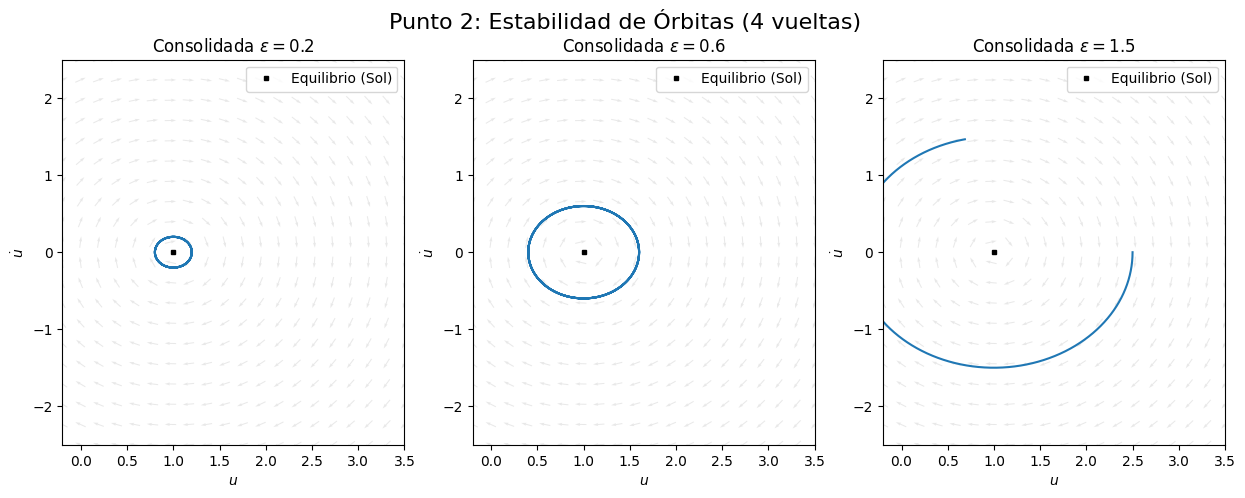

In [2]:
# =====================================================================
# --- 2. PUNTO 2: ESTUDIO CLÁSICO (delta = 0) ---
# =====================================================================

# FIGURA A: Desarrollo Inicial (theta < 2pi)
fig_fase1, axes1 = plt.subplots(1, 3, figsize=(15, 5))
fig_fase1.suptitle(r'Punto 2: Evolución en el Espacio de Fases ($\theta < 2\pi$)', fontsize=16)
eps_vals = [0.0, 0.5, 1.2]
colores = ['#2ca02c', '#9467bd', '#8c564b']

for ax, eps, col in zip(axes1, eps_vals, colores):
    dibujar_quiver(ax, alpha_base, 0.0)
    t, u, ud = integrar_sistema(eps, alpha_base, 0.0, vueltas=1, incompleto=True)
    ax.plot(u, ud, color=col, linewidth=2, label=f'$\epsilon={eps}$')
    ax.plot(u[0], ud[0], 'o', color=col)
    ax.set_title(f'Trayectoria $\epsilon = {eps}$')
    ax.plot(1/alpha_base, 0.0, 'ks', markersize=3,label='Equilibrio (Sol)' )
    ax.set_xlabel('$u$'); ax.set_ylabel('$\dot{u}$')
    ax.legend()


 # FIGURA B: Órbitas Consolidadas (4 vueltas)
fig_fase2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
fig_fase2.suptitle('Punto 2: Estabilidad de Órbitas (4 vueltas)', fontsize=16)
eps_cons = [0.2, 0.6, 1.5]

for ax, eps in zip(axes2, eps_cons):
     dibujar_quiver(ax, alpha_base, 0.0)
     t, u, ud = integrar_sistema(eps, alpha_base, 0.0, vueltas=4)
     ax.plot(u, ud, color='#1f77b4')
     ax.set_title(f'Consolidada $\epsilon = {eps}$')
     ax.plot(1/alpha_base, 0.0, 'ks', markersize=3,label='Equilibrio (Sol)' )
     ax.set_xlabel('$u$'); ax.set_ylabel('$\dot{u}$')
     ax.legend()

<>:18: SyntaxWarning: invalid escape sequence '\e'
<>:18: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_5542/1469692772.py:18: SyntaxWarning: invalid escape sequence '\e'
  ax_cart.plot(x[mascara], y[mascara], color=col, lw=2.5, label=f'$\epsilon={ep}$')


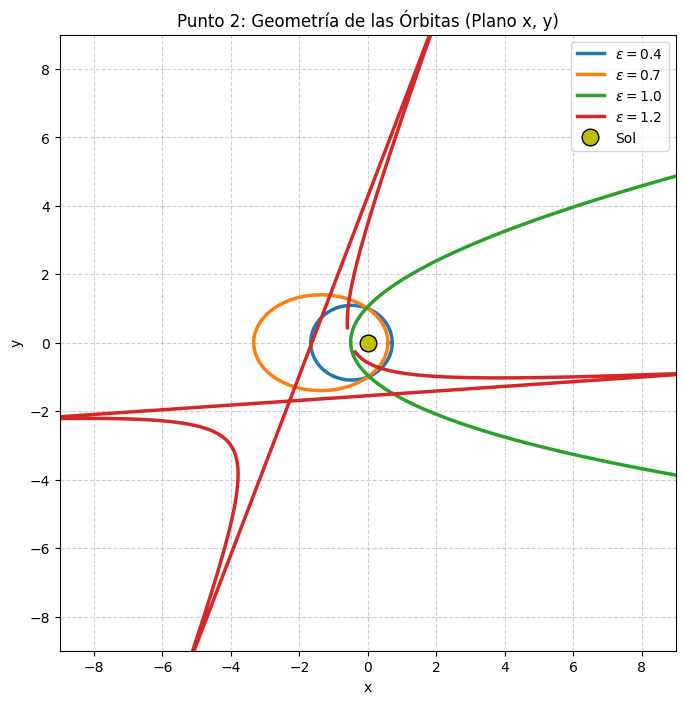

In [12]:
# --- PUNTO 2: Órbitas Cartesianas ---
fig_cart = plt.figure(figsize=(8, 8))
ax_cart = fig_cart.add_subplot(1, 1, 1)

eps_cart = [0.4, 0.7, 1.0, 1.2]
colores_c = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for ep, col in zip(eps_cart, colores_c):
    # Usamos alpha_base = 1.0 y delta = 0.0 (caso clásico)
    t, u, _ = integrar_sistema(ep, 1.0, 0.0, vueltas=1)

    r = 1 / u
    x = r * np.cos(t)
    y = r * np.sin(t)

    mascara = (np.abs(x) < 10) & (np.abs(y) < 10)

    ax_cart.plot(x[mascara], y[mascara], color=col, lw=2.5, label=f'$\epsilon={ep}$')

ax_cart.plot(0, 0, 'yo', markersize=12, markeredgecolor='black', label='Sol')
ax_cart.set_title('Punto 2: Geometría de las Órbitas (Plano x, y)')
ax_cart.set_xlabel('x')
ax_cart.set_ylabel('y')

# Forzamos los límites absolutos de la ventana
ax_cart.set_xlim(-9, 9)
ax_cart.set_ylim(-9, 9)

ax_cart.set_aspect('equal') # Mantiene la proporción redonda
ax_cart.grid(True, linestyle='--', alpha=0.6)
ax_cart.legend(loc='upper right')

plt.show()

3. Resolver el problema relativista para $δ = 0.05$ en las mismas condiciones iniciales del ítem anterior
y comparar. \
El efecto se conoce como precesión del perihelio y las mediciones sobre la órbita de Mercurio fueron
utilizadas por Albert Einstein como evidencia experimental de la Teoría General de la Relatividad.

<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:16: SyntaxWarning: invalid escape sequence '\d'
<>:17: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:16: SyntaxWarning: invalid escape sequence '\d'
<>:17: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_5542/2363971973.py:10: SyntaxWarning: invalid escape sequence '\d'
  fig_precesion.suptitle(f'Punto 3: Precesión del Perihelio ($\delta = {delta_rel}$ y α = 1)', fontsize=16)
/tmp/ipykernel_5542/2363971973.py:16: SyntaxWarning: invalid escape sequence '\d'
  ax_f.set_title("Espacio de Fases ($u, \dot{u}$)")
/tmp/ipykernel_5542/2363971973.py:17: SyntaxWarning: invalid escape sequence '\d'
  ax_f.set_xlabel('$u$'); ax_f.set_ylabel('$\dot{u}$')


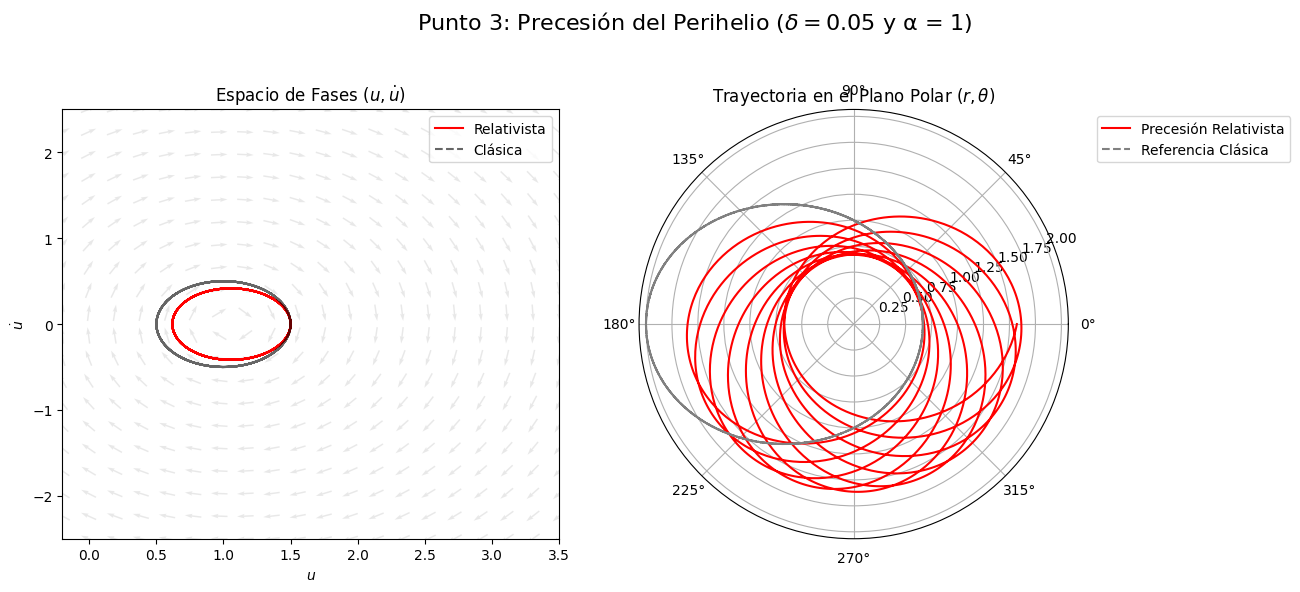

In [4]:
# =====================================================================
# --- 3. PUNTO 3: COMPARATIVA Y PRECESIÓN ---
# =====================================================================

# FIGURA C: Efecto de la corrección relativista
t_cl, u_cl, ud_cl = integrar_sistema(0.5, alpha_base, 0.0, vueltas=10)
t_re, u_re, ud_re = integrar_sistema(0.5, alpha_base, delta_rel, vueltas=10)

fig_precesion = plt.figure(figsize=(14, 6))
fig_precesion.suptitle(f'Punto 3: Precesión del Perihelio ($\delta = {delta_rel}$ y α = 1)', fontsize=16)

ax_f = fig_precesion.add_subplot(1, 2, 1)
dibujar_quiver(ax_f, alpha_base, delta_rel)
ax_f.plot(u_re, ud_re, 'r', linewidth=1.5, label='Relativista')
ax_f.plot(u_cl, ud_cl, color='black', linestyle='--', alpha=0.6, label='Clásica')
ax_f.set_title("Espacio de Fases ($u, \dot{u}$)")
ax_f.set_xlabel('$u$'); ax_f.set_ylabel('$\dot{u}$')
ax_f.legend(loc='upper right')

# Subplot: Plano Polar
ax_p = fig_precesion.add_subplot(1, 2, 2, projection='polar')
ax_p.plot(t_re, 1/u_re, 'r', linewidth=1.5, label='Precesión Relativista')
ax_p.plot(t_cl[:1000], (1/u_cl)[:1000], color='gray', linestyle='--', label='Referencia Clásica')
ax_p.set_title("Trayectoria en el Plano Polar ($r, \\theta$)")

# Leyenda movida fuera del gráfico para que no tape los datos
ax_p.legend(loc='upper left', bbox_to_anchor=(1.05, 1.0))

plt.tight_layout(rect=[0, 0, 0.95, 0.95]) # Ajuste de márgenes para el título
plt.show()


<>:29: SyntaxWarning: invalid escape sequence '\g'
<>:29: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_5542/1772493321.py:29: SyntaxWarning: invalid escape sequence '\g'
  ax3.set_title('$\\epsilon \geq 1$ (Abiertas)')


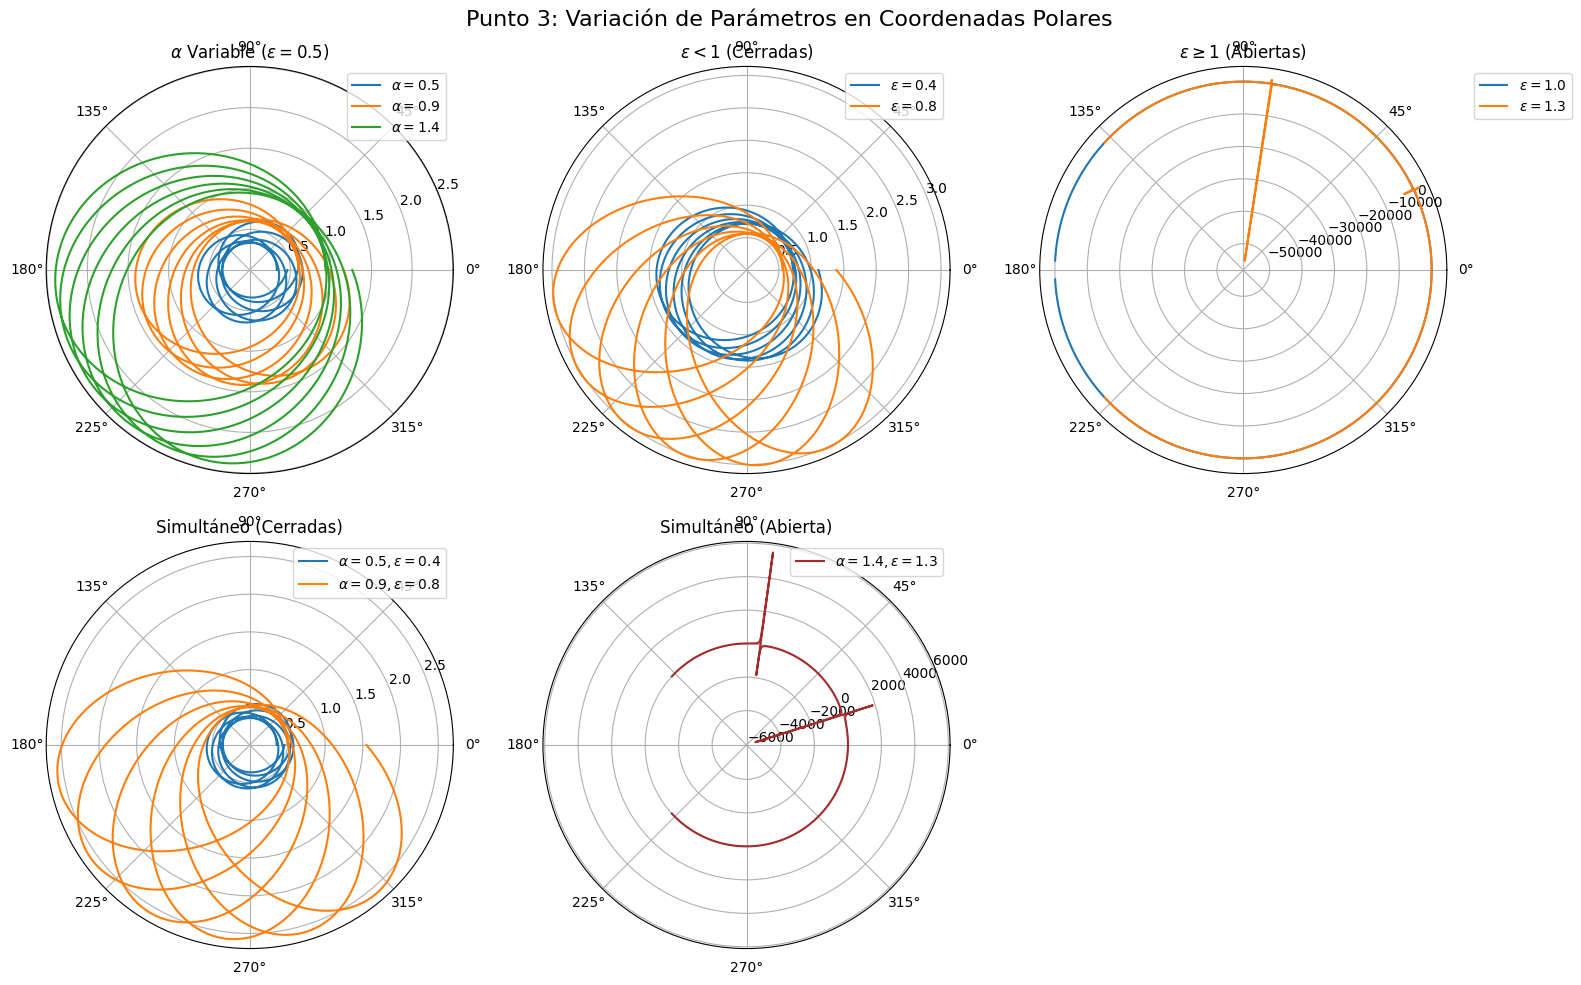

In [8]:
# =====================================================================
# --- VARIACIÓN DE PARÁMETROS (Grilla Polar Separada) ---
# =====================================================================

fig_var = plt.figure(figsize=(16, 10))
fig_var.suptitle('Punto 3: Variación de Parámetros en Coordenadas Polares', fontsize=16)

# 1. Variando Alpha (Epsilon 0.5)
ax1 = fig_var.add_subplot(2, 3, 1, projection='polar')
for al in [0.5, 0.9, 1.4]:
    t, u, _ = integrar_sistema(0.5, al, delta_rel, vueltas=6)
    ax1.plot(t, 1/u, label=f'$\\alpha={al}$')
ax1.set_title('$\\alpha$ Variable ($\\epsilon=0.5$)')
ax1.legend()

# 2. Variando Epsilon Cerradas (Alpha 1.0)
ax2 = fig_var.add_subplot(2, 3, 2, projection='polar')
for ep in [0.4, 0.8]:
    t, u, _ = integrar_sistema(ep, 1.0, delta_rel, vueltas=6)
    ax2.plot(t, 1/u, label=f'$\\epsilon={ep}$')
ax2.set_title('$\\epsilon < 1$ (Cerradas)')
ax2.legend()

# 3. Variando Epsilon Abiertas (Alpha 1.0)
ax3 = fig_var.add_subplot(2, 3, 3, projection='polar')
for ep in [1.0, 1.3]:
    t, u, _ = integrar_sistema(ep, 1.0, delta_rel, vueltas=1)
    ax3.plot(t, 1/u, label=f'$\\epsilon={ep}$')
ax3.set_title('$\\epsilon \geq 1$ (Abiertas)')
ax3.legend(loc='upper left', bbox_to_anchor=(1.05, 1.0))

# 4. Simultáneo (Cerradas)
ax4 = fig_var.add_subplot(2, 3, 4, projection='polar')
for al, ep in [(0.5, 0.4), (0.9, 0.8)]:
    t, u, _ = integrar_sistema(ep, al, delta_rel, vueltas=6)
    ax4.plot(t, 1/u, label=f'$\\alpha={al}, \\epsilon={ep}$')
ax4.set_title('Simultáneo (Cerradas)')
ax4.legend()

# 5. Simultáneo (Abierta)
ax5 = fig_var.add_subplot(2, 3, 5, projection='polar')
t, u, _ = integrar_sistema(1.3, 1.4, delta_rel, vueltas=1)
ax5.plot(t, 1/u, color='brown', label='$\\alpha=1.4, \\epsilon=1.3$')
ax5.set_title('Simultáneo (Abierta)')
ax5.legend()

plt.tight_layout()
plt.show()


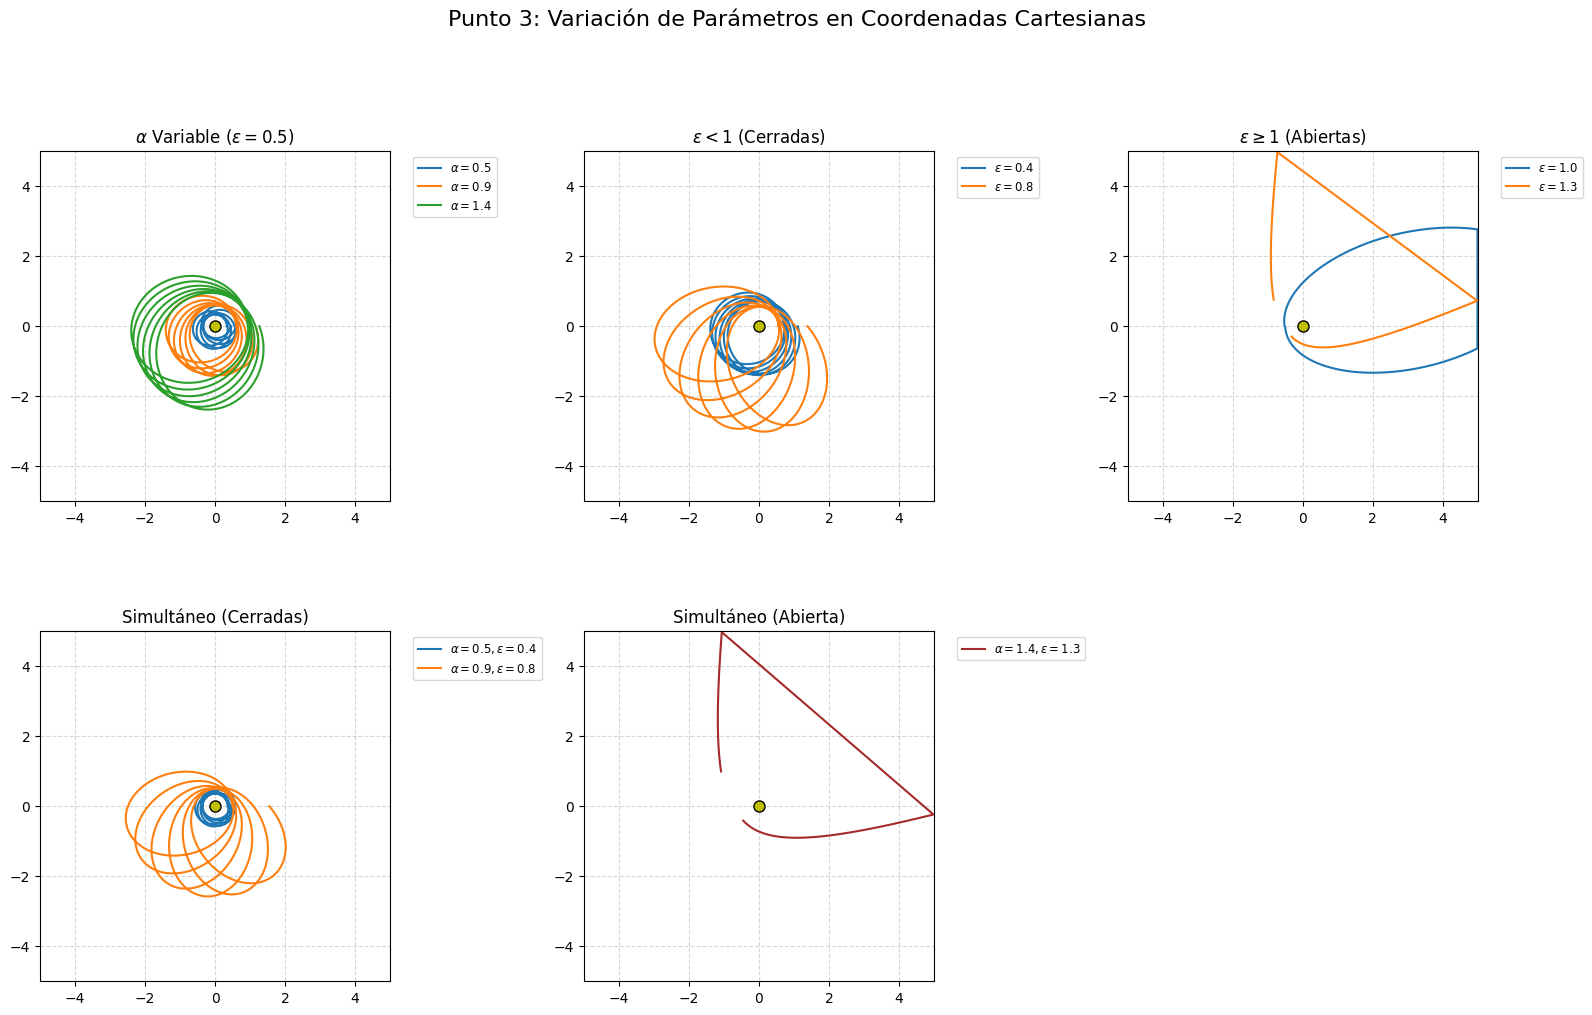

In [9]:
# =====================================================================
# --- VARIACIÓN DE PARÁMETROS (Grilla Cartesiana 10x10) ---
# =====================================================================

fig_var_cart = plt.figure(figsize=(16, 11))
fig_var_cart.suptitle('Punto 3: Variación de Parámetros en Coordenadas Cartesianas', fontsize=16)

# Grilla alineada a la izquierda (no centrada)
gs = GridSpec(2, 6, figure=fig_var_cart)
ax1 = fig_var_cart.add_subplot(gs[0, 0:2])
ax2 = fig_var_cart.add_subplot(gs[0, 2:4])
ax3 = fig_var_cart.add_subplot(gs[0, 4:6])
ax4 = fig_var_cart.add_subplot(gs[1, 0:2])
ax5 = fig_var_cart.add_subplot(gs[1, 2:4])

axes_cart = [ax1, ax2, ax3, ax4, ax5]

def graficar_cartesiano(ax, t, u, label_text, color=None):
    """Convierte a cartesianas y aplica el filtro de la caja 10x10 (-5 a 5)"""
    r = 1 / u
    x = r * np.cos(t)
    y = r * np.sin(t)

    # Filtro infalible para evitar que el infinito rompa el gráfico
    mascara = (np.abs(x) <= 5) & (np.abs(y) <= 5)

    if color:
        ax.plot(x[mascara], y[mascara], label=label_text, color=color, lw=1.5)
    else:
        ax.plot(x[mascara], y[mascara], label=label_text, lw=1.5)

# 1. Variando Alpha (Epsilon 0.5)
for al in [0.5, 0.9, 1.4]:
    t, u, _ = integrar_sistema(0.5, al, delta_rel, vueltas=6)
    graficar_cartesiano(ax1, t, u, f'$\\alpha={al}$')
ax1.set_title('$\\alpha$ Variable ($\\epsilon=0.5$)')

# 2. Variando Epsilon Cerradas (Alpha 1.0)
for ep in [0.4, 0.8]:
    t, u, _ = integrar_sistema(ep, 1.0, delta_rel, vueltas=6)
    graficar_cartesiano(ax2, t, u, f'$\\epsilon={ep}$')
ax2.set_title('$\\epsilon < 1$ (Cerradas)')

# 3. Variando Epsilon Abiertas (Alpha 1.0)
for ep in [1.0, 1.3]:
    t, u, _ = integrar_sistema(ep, 1.0, delta_rel, vueltas=1)
    graficar_cartesiano(ax3, t, u, f'$\\epsilon={ep}$')
ax3.set_title('$\\epsilon \\geq 1$ (Abiertas)')

# 4. Simultáneo (Cerradas)
for al, ep in [(0.5, 0.4), (0.9, 0.8)]:
    t, u, _ = integrar_sistema(ep, al, delta_rel, vueltas=6)
    graficar_cartesiano(ax4, t, u, f'$\\alpha={al}, \\epsilon={ep}$')
ax4.set_title('Simultáneo (Cerradas)')

# 5. Simultáneo (Abierta)
t, u, _ = integrar_sistema(1.3, 1.4, delta_rel, vueltas=1)
graficar_cartesiano(ax5, t, u, '$\\alpha=1.4, \\epsilon=1.3$', color='brown')
ax5.set_title('Simultáneo (Abierta)')

# Formato común
for ax in axes_cart:
    ax.plot(0, 0, 'yo', markersize=8, markeredgecolor='black', zorder=5)
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1.0), fontsize='small')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# =====================================================================
# --- ANIMACIÓN 3D (EXCLUSIVO PARA COLAB) ---
# =====================================================================
fig3d = plt.figure(figsize=(10, 8))
ax3d = fig3d.add_subplot(projection='3d')

t_a, u_a, _ = integrar_sistema(0.5, 1.0, 0.05, vueltas=12)
x_a = (1/u_a) * np.cos(t_a)
y_a = (1/u_a) * np.sin(t_a)
z_a = t_a

curva, = ax3d.plot([], [], [], 'r-', lw=1.5)
ax3d.set(xlim=(-3, 3), ylim=(-3, 3), zlim=(0, max(z_a)))
ax3d.set_xlabel('X'); ax3d.set_ylabel('Y'); ax3d.set_zlabel('Ángulo $\\theta$')
ax3d.set_title("Evolución 3D de la precesión (Resorte relativista)")

def update(i):
    step = i * 20
    curva.set_data(x_a[:step], y_a[:step])
    curva.set_3d_properties(z_a[:step])
    return curva,

ani = animation.FuncAnimation(fig3d, update, frames=len(t_a)//20, interval=25, blit=True)

# Cerrar la figura vacía y mostrar la animación en Colab
plt.close(fig3d)
HTML(ani.to_jshtml())